<a href="https://colab.research.google.com/github/MarinaVoit/python_for_ds_tasks/blob/main/Maryna_Voit_HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('yulu_rental.csv')

In [3]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])

india_season_map = {12: 1, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3, 9: 3, 10: 4, 11: 4}
df['weather_season_india'] = df['datetime'].dt.month.map(india_season_map)

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість колонок: {df.shape[1]}")
print(f"Назви колонок: {df.columns.tolist()}")

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Розмір таблиці у пам'яті: {memory_mb:.2f} MB")

Кількість рядків: 10886
Кількість колонок: 13
Назви колонок: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'weather_season_india']
Розмір таблиці у пам'яті: 1.08 MB


In [6]:
print(df['datetime'].dt.hour)

0         0
1         1
2         2
3         3
4         4
         ..
10881    19
10882    20
10883    21
10884    22
10885    23
Name: datetime, Length: 10886, dtype: int32


Набір даних містить 10886 рядків та 14 стовпців. А розмір таблиці у пам'яті: 1.12 MB.

Дані представлені з деталізацією до годин. Один рядок відповідає за показниками за 1 годину, оскільки часовий крок між записами становить 1 hour

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


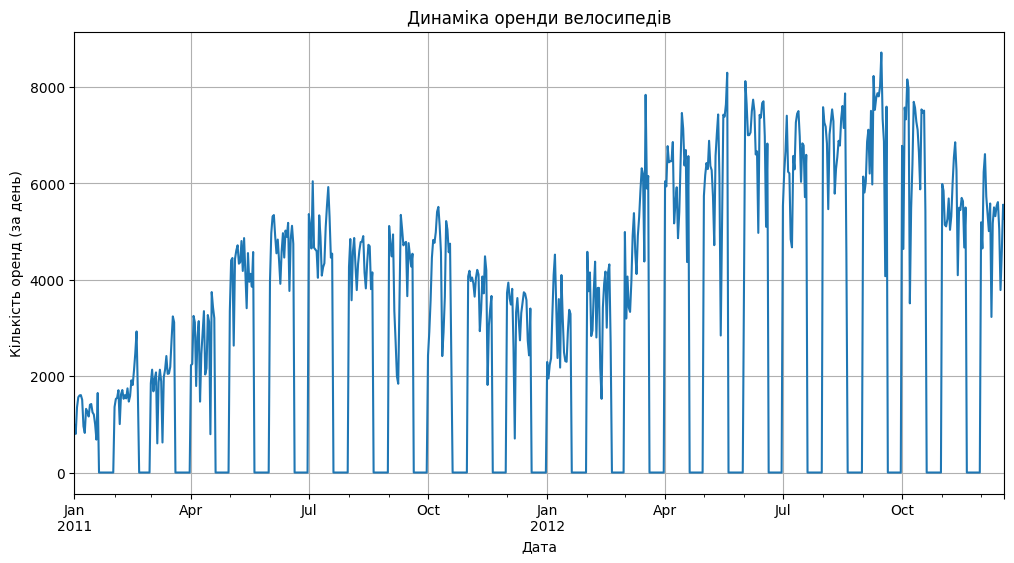

In [7]:
daily_count = df.resample('D', on='datetime')['count'].sum()

daily_count.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True,
    color='#1f77b4',
    xlabel='Дата',
    ylabel='Кількість оренд (за день)',
);


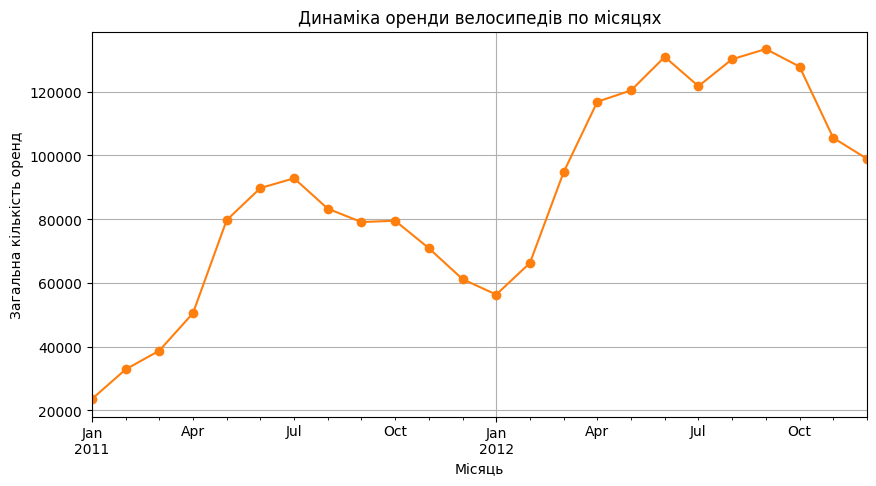

In [9]:
monthly_sum = df.resample('ME', on='datetime')['count'].sum()

monthly_sum.plot(
    kind='line',
    figsize=(10, 5),
    title='Динаміка оренди велосипедів по місяцях',
    marker='o',
    color='#ff7f0e',
    xlabel='Місяць',
    ylabel='Загальна кількість оренд',
    grid=True
);

 1. У наданому датасеті відсутні дані за останні дні кожного місяця (з 20-го числа і до кінця місяця). При використанні .resample('D') відсутні дні заповнюються нулями, через що лінія падає до нуля.
 Для побудови лінійного графіку без заломів та викривлень, варто агрегувати дані по тижням або місяцям.
 На графіку "Динаміка оренди велосипедів по місяцях" відсутні заломи, як на попередньому.
 2. У 2012 році загальний рівень оренд велосипедів суттєво вищий, ніж у 2011 році.
 3. На графіку чітко видно річну сезонність. Пікові періоди (квітень - жовтень): попит на оренду сягає максимуму завдяки сприятливим погодним умовам. Спад (листопад - лютий): різке зниження кількості оренд через похолодання, дощі чи сніг.
 4. Сильні падіння з низькими значеннями в теплу пору може вказувати на аномальні погодні умови - зливи, шторми або екстремальна температура. Стосовно низьких значень на початку 2011 року, може говорити про те, що сервіс оренди перебував на стадії запуску та розвитку.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

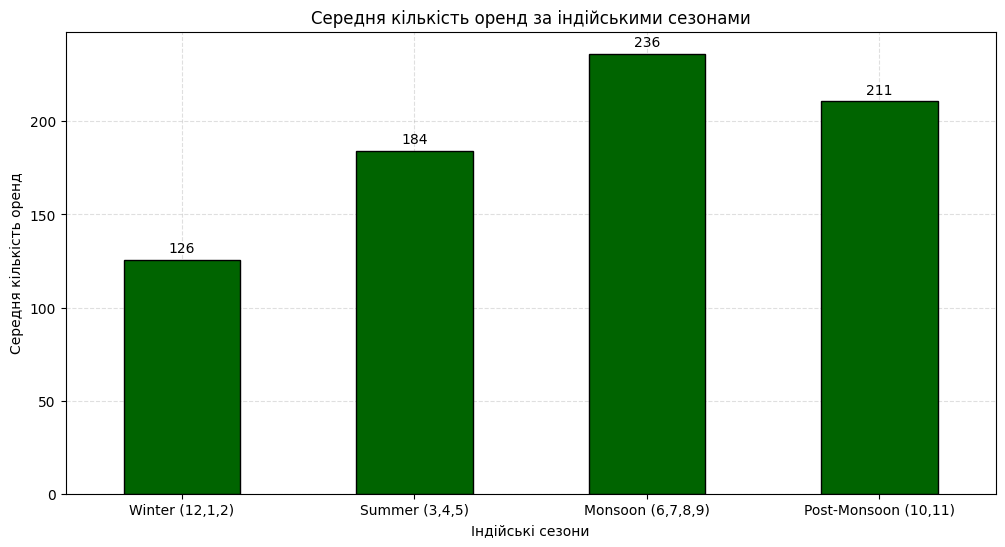

In [11]:
india_seasons = {
    1: 'Winter (12,1,2)',
    2: 'Summer (3,4,5)',
    3: 'Monsoon (6,7,8,9)',
    4: 'Post-Monsoon (10,11)'
}

season_mean = (
    df.groupby('weather_season_india')['count']
    .mean()
    .rename(index=india_seasons)
)

ax = season_mean.plot(
    kind='bar',
    figsize=(12, 6),
    title='Середня кількість оренд за індійськими сезонами',
    xlabel='Індійські сезони',
    ylabel='Середня кількість оренд',
    color='darkgreen',
    edgecolor='black',
    rot=0,
    grid=True
)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

1. Найбільша середня кількість оренд спостерігається у сезон Monsoon (червень - вересень) і становить 236 оренд на день.
2. Monsoon (червень - вересень)  у цей період спадає виснажлива літня спека, а погода залишається придатною для активних поїздок на відкритому повітрі. Winter (груднь - лютий) має найнижчі показники (126) можна пояснити похолоданням та менш комфортними погодними умовами для велосипедних прогулянок.
3. Оренда велосипедів у найпопулярніший сезон Monsoon більша приблизно в 1.9 раза, майже вдвічі порівняно з найменш популярним сезоном Winter.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


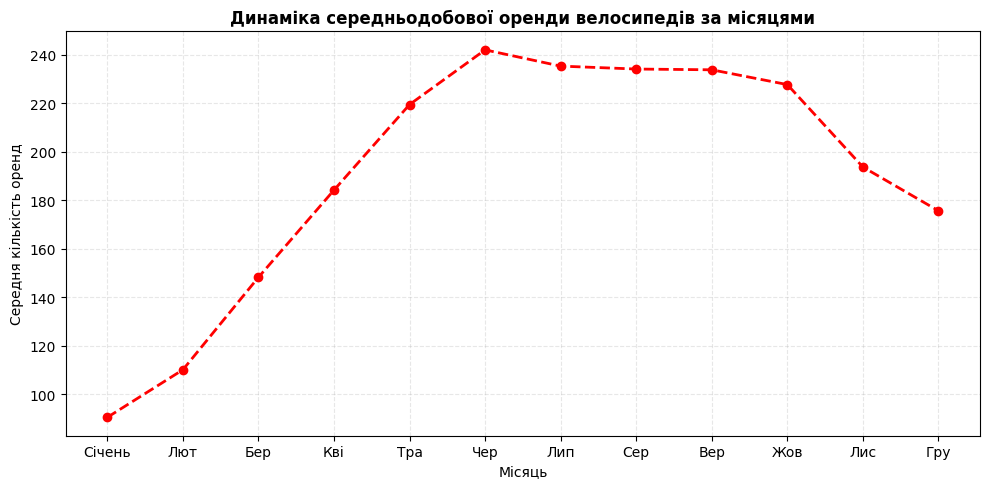

In [12]:
monthly_mean_3 = df.groupby(df['datetime'].dt.month)['count'].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean_3.index,
    monthly_mean_3.values,
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    zorder=3
)

plt.title('Динаміка середньодобової оренди велосипедів за місяцями', fontsize=12, fontweight='bold')
plt.xlabel('Місяць', fontsize=10)
plt.ylabel('Середня кількість оренд', fontsize=10)

plt.xticks(
    ticks=range(1, 13),
    labels=['Січень', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']
)

plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout();

1. Пік оренди спостерігається в червні - вересні(середня кількість оренди більше 240 в місяць в липні), а спад в грудні - лютому (середня оренда в січні менше 50).
2. Так, збігається ця закономірність з результатами з попереднього завдання. Завдяки цьому графіку ми можемо спостерігати конкретні місяці, а не сезон в цілому.
3. Зростання температури навесні та влітку створює комфортні умови для поїздок, що стимулює попит. Водночас надто низькі температури взимку суттєво знижують бажання користуватися відкритим транспортом. У зимовий період додаються фактори короткого світлового дня, снігу, ожеледиці чи холодного дощу, що робить велопоїздки менш безпечними та комфортними. Натомість тривалий світловий день улітку сприяє вечірнім прогулянкам.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

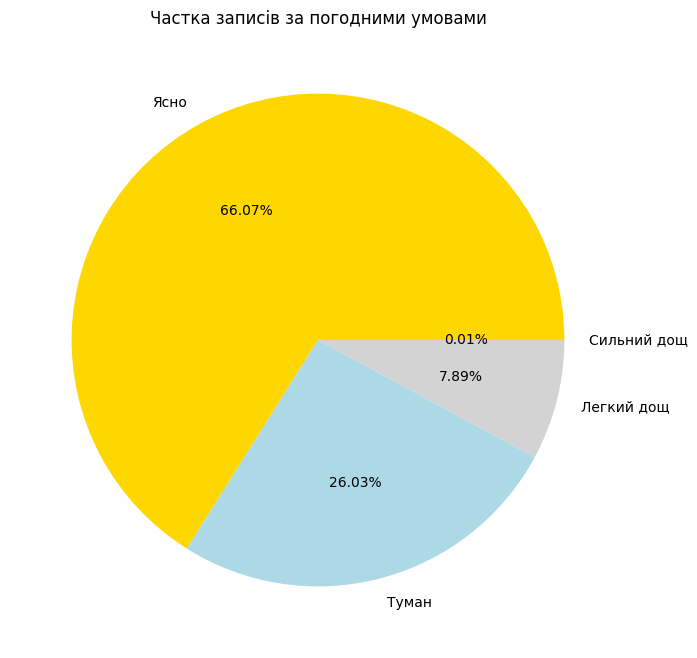

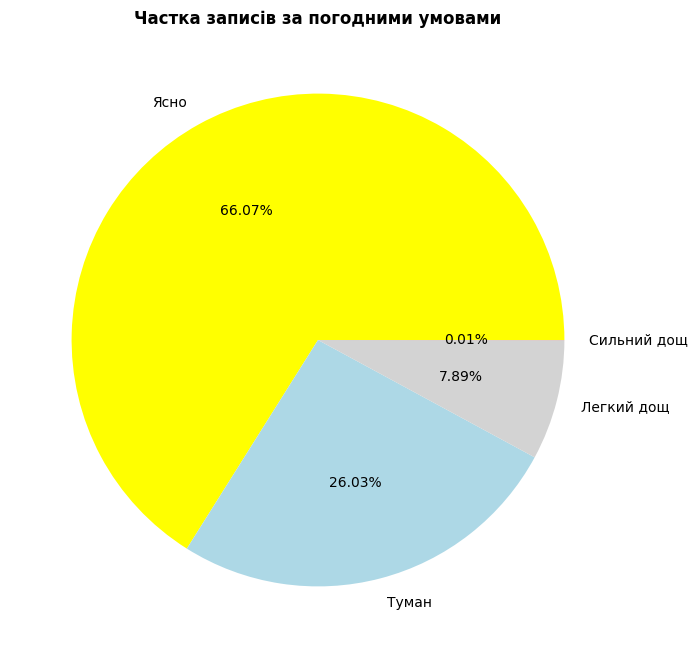

In [15]:
weather_counts = df['weather'].value_counts().sort_index()

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
custom_colors = ['yellow', 'lightblue', 'lightgray', 'salmon']

plt.figure(figsize=(8, 8))
plt.pie(
    weather_counts,
    labels=weather_labels,
    autopct='%.2f%%',
    colors=custom_colors
)
plt.title('Частка записів за погодними умовами', fontsize=12, fontweight='bold');

1. Переважає ясна погода, яка складає приблизно 66.07% від усіх днів у датасеті.
2. Так, є. Але їхня кількість критично мала, частка становить лише 0.01%.
3. Туман та легкий дощ помірно знижують попит (приблизно в сумі 34%), оскільки люди частіше обирають закритий транспорт або утримуються від прогулянок. Сильний дощ (0.01%): практично повністю зводить попит оренди велосипедів до нуля через несприятливі та небезпечні умови для пересування.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

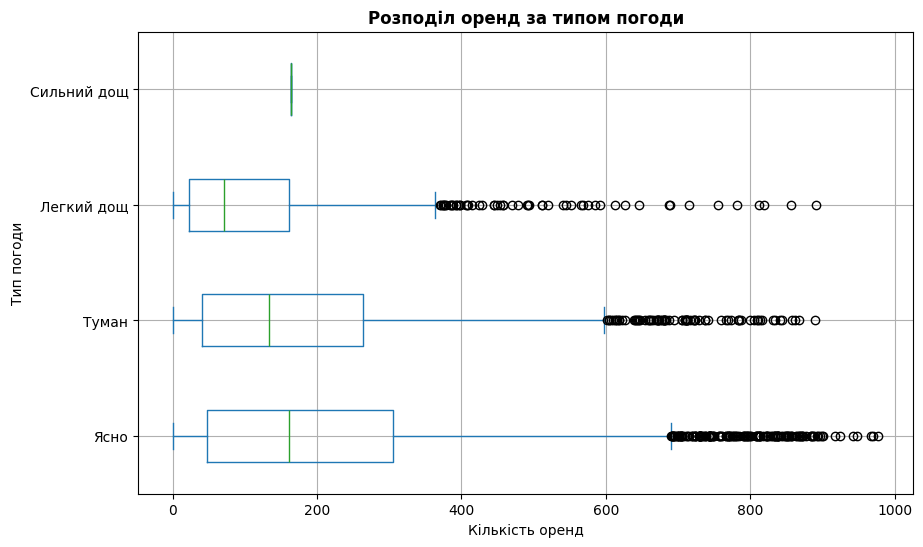

In [16]:
ax = df[['weather', 'count']].plot.box(
    by='weather',
    figsize=(10, 6),
    vert=False,
    grid=True
)

plt.title('Розподіл оренд за типом погоди', fontsize=12, fontweight='bold')
plt.xlabel('Кількість оренд', fontsize=10)
plt.ylabel('Тип погоди', fontsize=10)

plt.yticks(
    ticks=[1, 2, 3, 4],
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
);

1. Найбільший розкид спостерігається при ясній погоді. Її «коробка» та «вуса» найширші, охоплюючи діапазон від 0 до приблизно 900 оренд.
2. Так, викиди є. Вони присутні при трьох типах погоди: Ясно, Туман та Легкий дощ. При сильному дощі викидів немає.
3. При ясній погоді. Зелена вертикальна лінія всередині коробки знаходиться найправіше - приблизно на позначці 170 оренд. На другому місці - туман приблизно 140 оренд.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

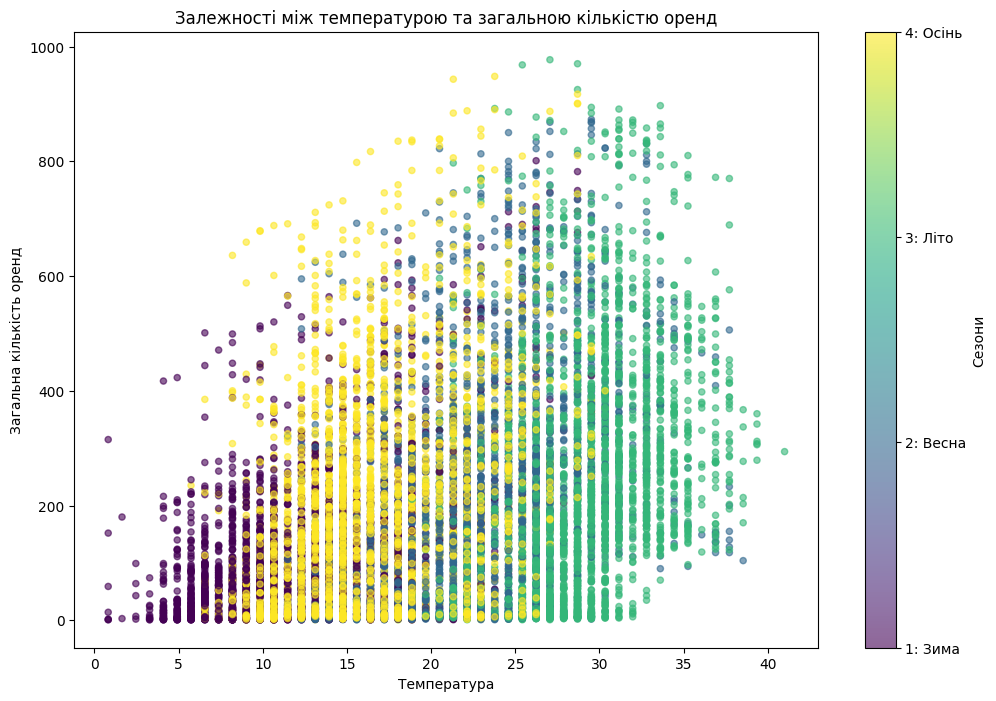

In [17]:
ax = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежності між температурою та загальною кількістю оренд',
    figsize=(12, 8),
    alpha=0.6,
    xlabel='Температура',
    ylabel='Загальна кількість оренд'
)

cbar = ax.collections[0].colorbar
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(['1: Зима', '2: Весна', '3: Літо', '4: Осінь'])

cbar.set_label('Сезони');

Так, зв'язок є.
З підвищенням температури до приблизно 25–30°C кількість оренд впевнено зростає. Після досягнення 30°C і вище попит починає знижуватися, оскільки надмірна спека стає некомфортною для активних велопрогулянок. Найвищий попит спостерігається в теплі сезони (жовто-зелені точки відповідають літу та початку осені), тоді як у холодну пору (темно-фіолетові точки - зима та рання весна) кількість оренд мінімальна.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

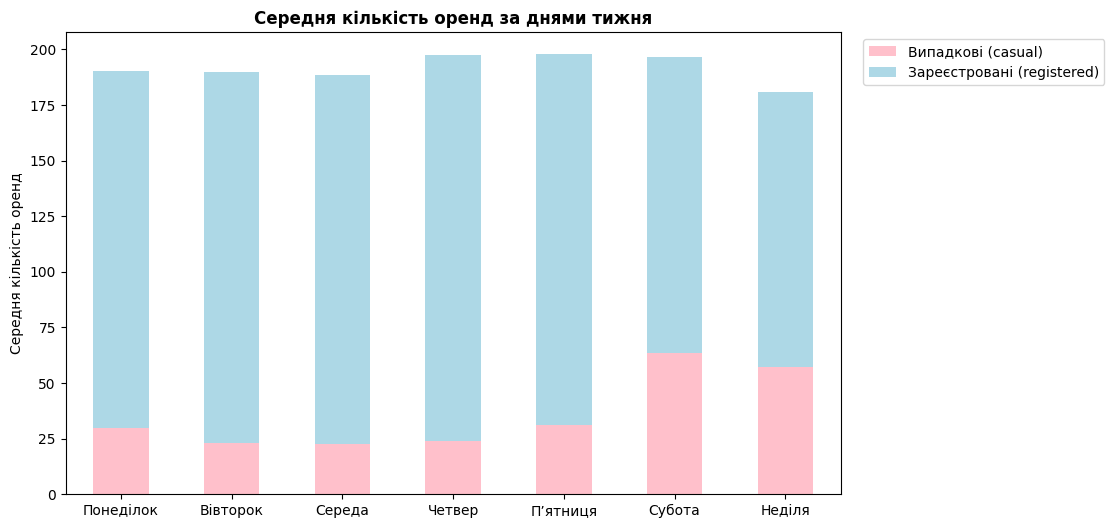

In [24]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              'Friday', 'Saturday', 'Sunday']

df_grouped = (
    df.groupby(df['datetime'].dt.day_name())[['casual', 'registered']]
      .mean()
      .reindex(days_order)
)

ax = df_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['pink', 'lightblue']
)

ax.set_xticklabels(['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'П’ятниця', 'Субота', 'Неділя'])

plt.title('Середня кількість оренд за днями тижня', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylabel('Середня кількість оренд', fontsize=10)
plt.legend(
    ['Випадкові (casual)', 'Зареєстровані (registered)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=0);

1. Найвищу кількість оренд серед зареєстрованих користувачів можемо спостерігати з четверга по суботу, причому пік припадає на п'ятницю. Також спостерігається підвищена кількість оренд серед випадкових користувачів саме у суботу та неділю.
2. Це може бути пов'язано з тим, що зареєстровані користувачі частіше використовують велосипеди регулярно, наприклад для повсякденних справ. Тому їхня активність залишається високою протягом робочого тижня. Водночас випадкові користувачі частіше орендують велосипеди для відпочинку, тому у вихідні їхня кількість збільшується, коли люди мають більше вільного часу.